<div style="direction: rtl !important; text-align: right !important; font-family: inherit;">

<h2 style="direction: rtl !important; text-align: right !important; font-family: inherit; font-size: 1.5em; font-weight: bold; color: #2c3e50; border-bottom: 2px solid #3498db; padding-bottom: 5px;">המרת הקבצים לפורמט אחיד </h2>

<p style="direction: rtl !important; text-align: right !important; font-family: inherit; line-height: 1.6;">
כחלק מההכנה להרצת מנוע ה-OCR, נדרש להביא את הקבצים לפורמט אחיד המותאם לעיבוד ממוחשב. בסקריפט הבא נמיר אוטומטית את עמודי מסמכי ה-Word והPDF לתמונות JPG ברזולוציה גבוהה (300 DPI) .
</p>
</div>

In [1]:
import os
import pandas as pd
from docx2pdf import convert # This method requires Microsoft Word to be installed on the machine.
import pymupdf
import matplotlib.pyplot as plt

C:\Users\user\PycharmProjects\Project.DS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Consts
RAW_DATA_DIR = "./data"
CLEAN_DATA_DIR = "./dataset_images"

# 300 DPI (dots per inch) is the classic threshold
# where normal eyes at a standard viewing distance of 12 inches (30 cm)
# can no longer see individual ink dots.
OUTPUT_RESOLUTION = 300

### Data Loading

In [3]:
file_records = []

for current_dir, _, filenames in os.walk(RAW_DATA_DIR):
    for filename in filenames:
        full_path = os.path.join(current_dir, filename)
        extension = os.path.splitext(filename)[1].lower()

        file_records.append({
            "filename": filename,
            "extension": extension,
            "path": full_path,
            "size_bytes": os.path.getsize(full_path),
        })

files_df = pd.DataFrame(file_records)
#display(files_df)
print(f"Total input files: {len(files_df)}")


Total input files: 50


### Data Discovery

In [4]:
files_df.head()

,filename,extension,path,size_bytes
0,passport1.jpg,.jpg,./data\passports_images\passport1.jpg,378077
1,passport2.jpg,.jpg,./data\passports_images\passport2.jpg,379185
2,passport3.jpeg,.jpeg,./data\passports_images\passport3.jpeg,186763
3,passport_on_table.png,.png,./data\passports_images\passport_on_table.png,1820023
4,P_AU_A0091000_L1_B1_A1_D1.jpg,.jpg,./data\passports_images\with_photo\P_AU_A00910...,3659312


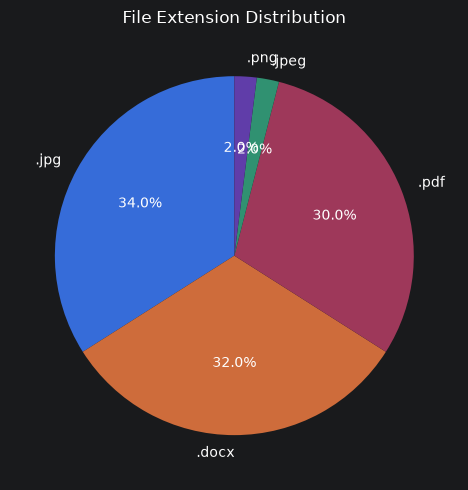

In [5]:
files_df["extension"].value_counts().plot(
    kind="pie",
    figsize=(5, 5),
    autopct="%1.1f%%",
    startangle=90,
    ylabel="",
    title="File Extension Distribution",
)

plt.tight_layout()
plt.show()

### Data Filtering

In [6]:
extensions_to_process = [".pdf", ".docx", ".doc"]

documents_df = (
    files_df[
        files_df["extension"].isin(extensions_to_process)
        & ~files_df["filename"].str.startswith(("~$", "~"))
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Documents to process: {len(documents_df)}")
print(f"Removed files: {(len(files_df) - len(documents_df))}")
print("Filtered document types numbers:")
print(documents_df["extension"].value_counts())

Documents to process: 31
Removed files: 19
Filtered document types numbers:
extension
.docx    16
.pdf     15
Name: count, dtype: int64


### Documents to images transformation

In [7]:
def extract_pdf(pdf_path, original_path):
    base_name = os.path.splitext(os.path.basename(original_path))[0]

    extracted_images = []

    with pymupdf.open(pdf_path) as pdf_document:
        for page_num in range(len(pdf_document)):
            page = pdf_document.load_page(page_num)

            image_path = os.path.join(CLEAN_DATA_DIR, f"{base_name}_page_{page_num + 1}.jpg")

            page.get_pixmap(dpi=OUTPUT_RESOLUTION, alpha=False).save(image_path)

            extracted_images.append(image_path)

    return extracted_images


def extract_docx(docx_path):
    base_name = os.path.splitext(os.path.basename(docx_path))[0]

    tmp_pdf = os.path.join(CLEAN_DATA_DIR, f"{base_name}_tmp.pdf")

    try:
        convert(docx_path, tmp_pdf)
        return extract_pdf(tmp_pdf, docx_path)

    finally:
        if os.path.exists(tmp_pdf):
            os.remove(tmp_pdf)

In [8]:
# Create output folder
os.makedirs(CLEAN_DATA_DIR, exist_ok=True)

In [9]:
documents_df["status"] = "pending"
documents_df["page_count"] = 0
documents_df["output_images"] = None
documents_df["error"] = None

for index, row in documents_df.iterrows():
    source_path = row["path"]
    extension = row["extension"]

    print(
        f"[{index + 1}/{len(documents_df)}] "
        f"Processing: {source_path}"
    )

    try:
        if extension == ".pdf":
            output_images = extract_pdf(
                pdf_path=source_path,
                original_path=source_path
            )

        else:
            output_images = extract_docx(source_path)

        documents_df.at[index, "status"] = "success"
        documents_df.at[index, "page_count"] = len(output_images)
        documents_df.at[index, "output_images"] = output_images

    except Exception as error:
        documents_df.at[index, "status"] = "failed"
        documents_df.at[index, "error"] = str(error)

#display(documents_df)
print("\nProcessing complete.")
print(documents_df["status"].value_counts())

[1/31] Processing: ./data\pdf\PDF_Normal_Doc_1.pdf
[2/31] Processing: ./data\pdf\PDF_Normal_Doc_10.pdf
[3/31] Processing: ./data\pdf\PDF_Normal_Doc_2.pdf
[4/31] Processing: ./data\pdf\PDF_Normal_Doc_3.pdf
[5/31] Processing: ./data\pdf\PDF_Normal_Doc_4.pdf
[6/31] Processing: ./data\pdf\PDF_Normal_Doc_5.pdf
[7/31] Processing: ./data\pdf\PDF_Normal_Doc_6.pdf
[8/31] Processing: ./data\pdf\PDF_Normal_Doc_7.pdf
[9/31] Processing: ./data\pdf\PDF_Normal_Doc_8.pdf
[10/31] Processing: ./data\pdf\PDF_Normal_Doc_9.pdf
[11/31] Processing: ./data\pdf\edge_cases\PDF_Edge_Case_11.pdf
[12/31] Processing: ./data\pdf\edge_cases\PDF_Edge_Case_12.pdf
[13/31] Processing: ./data\pdf\edge_cases\PDF_Edge_Case_13.pdf
[14/31] Processing: ./data\pdf\edge_cases\PDF_Edge_Case_14.pdf
[15/31] Processing: ./data\pdf\edge_cases\PDF_Edge_Case_15.pdf
[16/31] Processing: ./data\word\Word_Normal_Doc_1.docx


100%|██████████| 1/1 [00:02<00:00,  2.12s/it]


[17/31] Processing: ./data\word\Word_Normal_Doc_10.docx


100%|██████████| 1/1 [00:01<00:00,  1.31s/it]


[18/31] Processing: ./data\word\Word_Normal_Doc_2.docx


...

[30/31] Processing: ./data\word\edge_cases\Word_Edge_Case_15.docx


100%|██████████| 1/1 [00:02<00:00,  2.04s/it]


[31/31] Processing: ./data\word\edge_cases\Word_Edge_Case_16.docx


100%|██████████| 1/1 [00:01<00:00,  1.24s/it]



Processing complete.
status
success    31
Name: count, dtype: int64


### Final Data Discovery

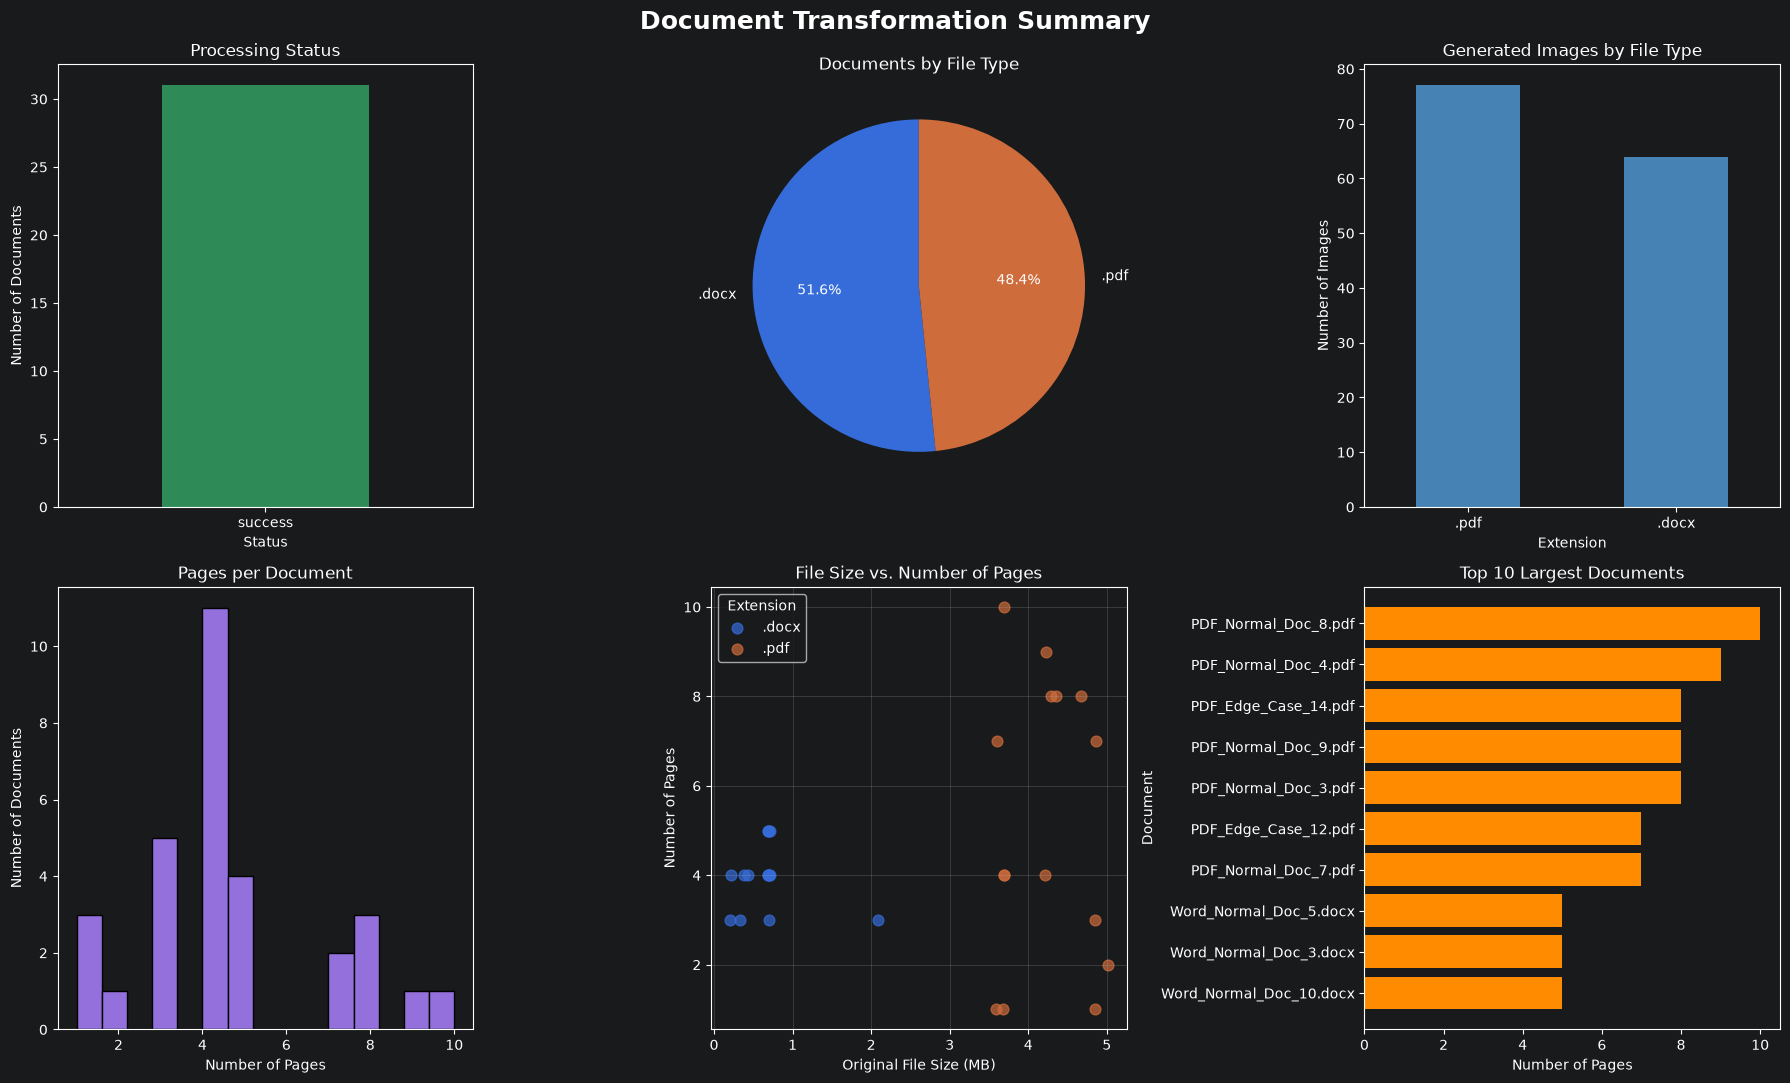

In [10]:
plot_df = documents_df.copy()
plot_df["page_count"] = pd.to_numeric(plot_df["page_count"], errors="coerce").fillna(0)
plot_df["size_mb"] = (pd.to_numeric(plot_df["size_bytes"], errors="coerce") / (1024 ** 2))
successful_df = plot_df[ plot_df["status"] == "success" ].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Processing status
status_counts = plot_df["status"].value_counts()
status_counts.plot(
    kind="bar",
    ax=axes[0, 0],
    color=["seagreen", "tomato", "orange"],
)

axes[0, 0].set_title("Processing Status")
axes[0, 0].set_xlabel("Status")
axes[0, 0].set_ylabel("Number of Documents")
axes[0, 0].tick_params(axis="x", rotation=0)


# 2. Documents by extension
extension_counts = plot_df["extension"].value_counts()
extension_counts.plot(
    kind="pie",
    ax=axes[0, 1],
    autopct="%1.1f%%",
    startangle=90,
    ylabel="",
)

axes[0, 1].set_title("Documents by File Type")


# 3. Total generated pages by extension
pages_by_extension = successful_df.groupby("extension")["page_count"].sum().sort_values(ascending=False)
pages_by_extension.plot(
    kind="bar",
    ax=axes[0, 2],
    color="steelblue",
)

axes[0, 2].set_title("Generated Images by File Type")
axes[0, 2].set_xlabel("Extension")
axes[0, 2].set_ylabel("Number of Images")
axes[0, 2].tick_params(axis="x", rotation=0)


# 4. Page-count distribution
successful_df["page_count"].plot(
    kind="hist",
    bins=15,
    ax=axes[1, 0],
    color="mediumpurple",
    edgecolor="black",
)

axes[1, 0].set_title("Pages per Document")
axes[1, 0].set_xlabel("Number of Pages")
axes[1, 0].set_ylabel("Number of Documents")


# 5. File size compared with page count
for extension, group in successful_df.groupby("extension"):
    axes[1, 1].scatter(
        group["size_mb"],
        group["page_count"],
        label=extension,
        alpha=0.7,
        s=60
    )

axes[1, 1].set_title("File Size vs. Number of Pages")
axes[1, 1].set_xlabel("Original File Size (MB)")
axes[1, 1].set_ylabel("Number of Pages")
axes[1, 1].legend(title="Extension")
axes[1, 1].grid(alpha=0.3)


# 6. Ten documents with the most pages
top_documents = successful_df.nlargest(10, "page_count").sort_values("page_count")
axes[1, 2].barh(top_documents["filename"], top_documents["page_count"], color="darkorange")
axes[1, 2].set_title("Top 10 Largest Documents")
axes[1, 2].set_xlabel("Number of Pages")
axes[1, 2].set_ylabel("Document")


plt.suptitle("Document Transformation Summary", fontsize=18, fontweight="bold")

plt.tight_layout()
plt.show()